In [3]:
import pandas as pd
import numpy as np
import janitor
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
warnings.filterwarnings('ignore')

In [51]:
childcare_costs=pd.read_csv("data_final.csv")

In [50]:
childcare_costs.shape

(930, 63)

Check Missing Values

In [47]:
null_columns = childcare_costs.columns[childcare_costs.isnull().any()]
null_summary = childcare_costs[null_columns].isnull().sum()
print(null_summary)

mcsa    558
dtype: int64


In [48]:
childcare_costs['mcsa'].isnull().mean() * 100

np.float64(60.0)

In [7]:
childcare_costs_cleaned=childcare_costs.dropna(subset=['mcsa'])

Check Duplicates

In [8]:
childcare_costs.duplicated().sum()

np.int64(0)

In [9]:
childcare_costs.dtypes

state_name                    object
county_name                   object
county_fips_code               int64
studyyear                      int64
emr_16                       float64
femr_16                      float64
memr_16                      float64
emr_20to64                   float64
femr_20to64                  float64
memr_20to64                  float64
unr_16                       float64
funr_16                      float64
munr_16                      float64
unr_20to64                   float64
funr_20to64                  float64
munr_20to64                  float64
flfpr_20to64                 float64
flfpr_20to64_under6          float64
flfpr_20to64_6to17           float64
flfpr_20to64_under6_6to17    float64
mlfpr_20to64                 float64
pr_f                         float64
pr_p                         float64
mfi_2022                       int64
mhi_2022                       int64
me_2022                        int64
fme_2022                       int64
m

In [10]:
data_numeric=childcare_costs_cleaned.remove_columns(['state_name','county_name','county_fips_code','studyyear'])
data_numeric.describe()

,emr_16,femr_16,memr_16,emr_20to64,femr_20to64,memr_20to64,unr_16,funr_16,munr_16,unr_20to64,funr_20to64,munr_20to64,flfpr_20to64,flfpr_20to64_under6,flfpr_20to64_6to17,flfpr_20to64_under6_6to17,mlfpr_20to64,pr_f,pr_p,mfi_2022,mhi_2022,me_2022,fme_2022,mme_2022,totalpop,onerace,onerace_w,onerace_b,onerace_i,onerace_a,onerace_h,onerace_other,tworaces,hispanic,households,h_under6_bothwork,h_under6_fwork,h_under6_mwork,h_under6_singlem,h_6to17_bothwork,h_6to17_fwork,h_6to17_mwork,h_6to17_singlem,emp_m,memp_m,femp_m,emp_service,memp_service,femp_service,emp_sales,memp_sales,femp_sales,emp_n,memp_n,femp_n,emp_p,memp_p,femp_p,mcsa
count,35417.000000,35417.000000,35417.000000,35417.000000,35417.000000,35417.000000,35417.00000,35417.000000,35417.000000,35417.000000,35417.000000,35417.000000,35417.000000,35417.000000,35417.000000,35417.000000,35417.000000,35417.000000,35417.000000,35417.000000,35417.000000,35417.000000,35417.000000,35417.000000,3.541700e+04,35417.000000,35417.000000,35417.000000,35417.000000,35417.000000,35417.000000,35417.000000,35417.000000,35417.000000,3.541700e+04,35417.000000,35417.000000,35417.000000,35417.000000,35417.000000,35417.000000,35417.000000,35417.000000,35417.000000,35417.000000,35417.000000,35417.000000,35417.000000,35417.000000,35417.000000,35417.000000,35417.000000,35417.000000,35417.000000,35417.000000,35417.000000,35417.000000,35417.000000,35417.000000
mean,54.913471,51.032803,59.010182,68.890756,64.020259,72.413095,6.81135,6.419838,7.162253,6.330118,5.944863,6.674597,69.724398,69.422825,78.387308,66.786058,78.045221,11.495008,15.773363,74747.456815,60329.825931,35329.344721,28384.724341,43070.681961,1.086496e+05,97.255660,82.808696,9.118757,1.752509,1.280487,0.075639,2.216071,2.744490,9.195827,4.038337e+04,3024.652257,1913.490951,155.035774,2095.601830,7001.172290,3107.170173,429.839682,4235.919445,31.584242,27.002298,36.783898,17.900042,13.270139,23.247161,21.548581,13.230587,31.081057,12.841336,22.810057,1.366381,16.143355,23.704574,7.538978,107.138054
std,8.268840,7.419502,10.108970,9.558016,10.958297,11.740931,3.49825,3.538389,3.980015,3.406359,3.454765,3.936405,7.919300,12.908237,8.713173,13.457072,11.008092,5.878904,6.678600,18672.203697,16166.731081,6844.804005,5912.175354,9066.118768,3.494371e+05,2.767311,16.406484,14.487870,6.721413,2.546076,0.497396,3.951489,2.767475,14.345547,1.229960e+05,9543.469537,7068.745300,518.449756,7431.477188,21014.780376,11779.586101,1313.806000,15043.498643,6.718905,8.164102,6.446313,3.634498,4.460393,4.793064,3.383331,3.726755,4.726098,4.265883,6.777428,1.471304,5.690340,7.748014,4.312455,37.752651
min,11.000000,13.600000,8.000000,11.200000,0.000000,7.700000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,0.000000,0.000000,8.200000,0.000000,0.000000,15099.000000,14013.000000,5786.000000,5877.000000,4957.000000,4.100000e+01,47.800000,3.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.200000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.980000
25%,49.500000,46.000000,53.000000,63.300000,58.600000,66.700000,4.40000,4.100000,4.500000,4.000000,3.700000,4.100000,64.600000,62.700000,73.900000,59.600000,73.500000,7.400000,11.100000,62625.000000,49872.000000,31190.000000,24870.000000,37525.000000,1.148100e+04,96.700000,75.700000,0.700000,0.200000,0.300000,0.000000,0.300000,1.300000,1.900000,4.385000e+03,256.000000,144.000000,5.000000,181.000000,679.000000,247.000000,38.000000,364.000000,27.000000,21.300000,32.600000,15.600000,10.400000,20.200000,19.400000,10.800000,28.200000,9.900000,18.200000,0.600000,11.900000,18.000000,4.500000,82.400000
50%,55.400000,51.200000,60.000000,69.900000,65.300000,74.300000,6.30000,5.900000,6.600000,5.800000,5.400000,6.000000,70.200000,70.300000,79.100000,67.500000,80.500000,10.500000,14.900000,72304.000000,58113.000000,34478

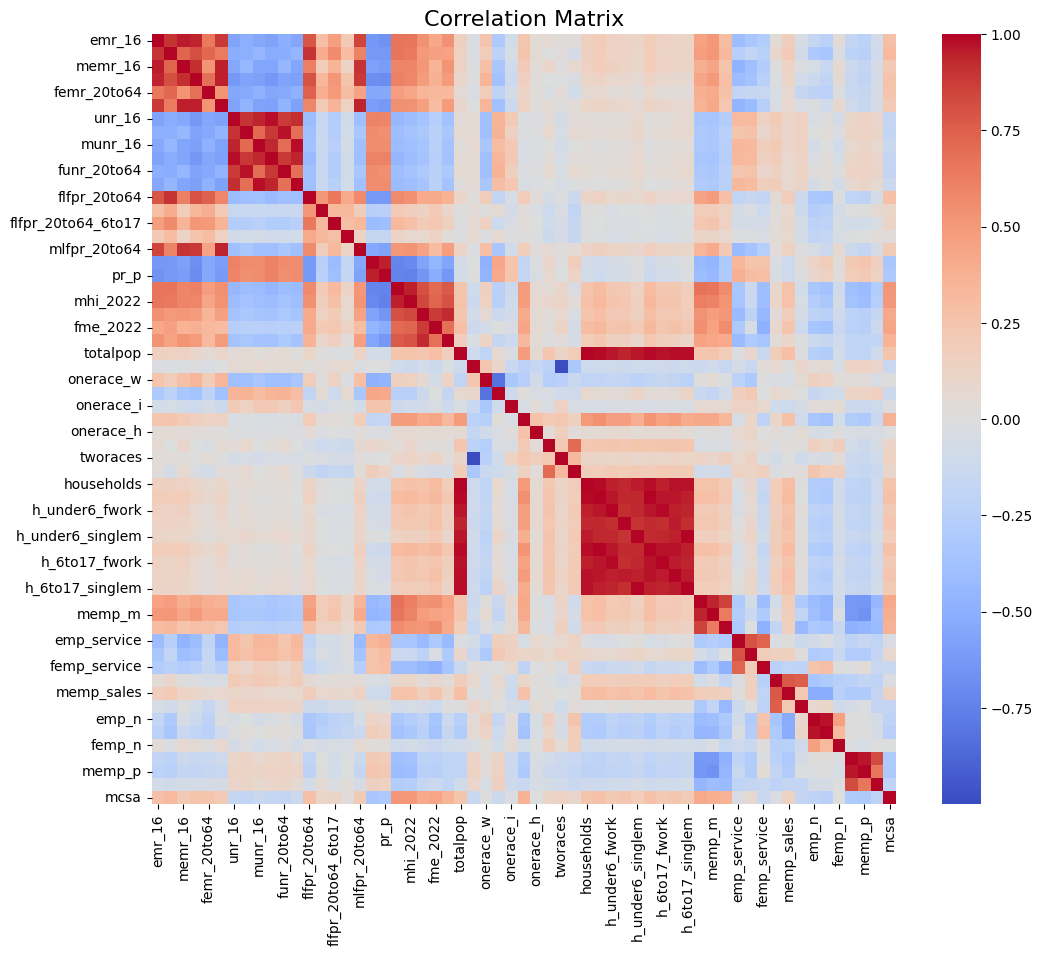

In [12]:
correlation_matrix=data_numeric.corr()
plt.figure(figsize=(12, 10))

# Create a heatmap
sns.heatmap(
    correlation_matrix, 
    fmt=".2f",            # Format to 2 decimal places
    cmap="coolwarm",       # Color map
    cbar=True             # Show color bar
)

# Add title
plt.title("Correlation Matrix", fontsize=16)
plt.show()

In [13]:
def correlatedCols(df, cutoff=0.5):
  """
  Returns a dataframe of combinations of variables that have a correlation higher than the specified cutoff.
  df: dataframe
  cutoff: correlation value; default = 0.5
  """
  drop_pairs = set()
  cols = df.columns
  for i in range(0, df.shape[1]):
    for j in range(0, i+1):
      drop_pairs.add((cols[i], cols[j]))

  corr_unstack = pd.DataFrame(df.corr().unstack())
  corr_unstack.drop(labels=drop_pairs, inplace=True)
  corr_unstack.reset_index(inplace=True)
  corr_unstack.columns = ['Col 1', 'Col 2', 'Correlation']
  corr_unstack['Sign'] = corr_unstack['Correlation'].apply(lambda x: '+' if x >= 0 else '-')
  corr_unstack['Correlation'] = corr_unstack['Correlation'].abs()
  corr_unstack = corr_unstack.sort_values(by='Correlation', ascending=False)
  corr_unstack = corr_unstack.reset_index(drop=True)

  return corr_unstack[corr_unstack['Correlation'] > cutoff]

In [14]:
correlatedCols(data_numeric)

,Col 1,Col 2,Correlation,Sign
0,onerace,tworaces,0.999994,-
1,totalpop,households,0.996198,+
2,h_under6_singlem,h_6to17_singlem,0.995399,+
3,h_under6_bothwork,h_6to17_bothwork,0.994516,+
4,h_under6_fwork,h_6to17_fwork,0.991045,+
5,totalpop,h_under6_bothwork,0.988153,+
6,households,h_under6_bothwork,0.985943,+
7,totalpop,h_6to17_bothwork,0.985470,+
8,unr_16,unr_20to64,0.983076,+
9,totalpop,h_6to17_mwork,0.981731,+


In [15]:
data_numeric.shape

(35417, 59)

How have childcare costs as measured by mcsa (median weekly price for school-aged kids in childcare centers) changed over time?

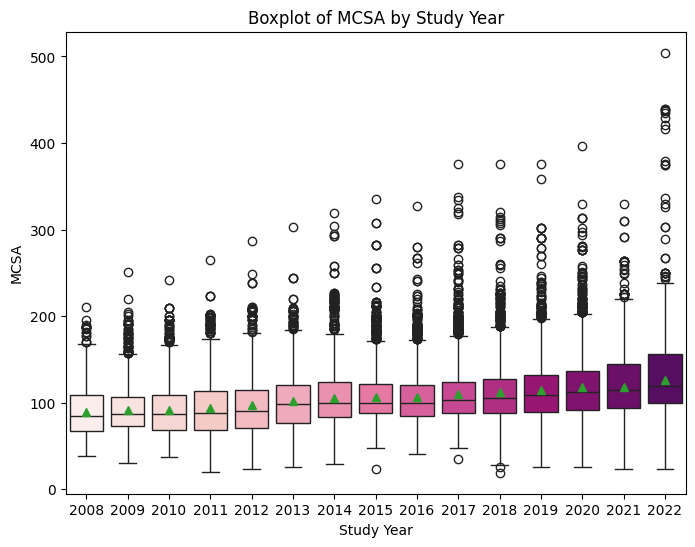

In [16]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    x='studyyear', 
    y='mcsa', 
    data=childcare_costs, 
    palette="RdPu",  # Equivalent to "scale_fill_distiller(palette = 'RdPu')"
    showmeans=True  # Optional: Show means for better insights
)

# Customize transparency (equivalent to alpha)
plt.gca().patch.set_alpha(0.8)

# Add labels and title
plt.xlabel("Study Year")
plt.ylabel("MCSA")
plt.title("Boxplot of MCSA by Study Year")

# Display the plot
plt.show()

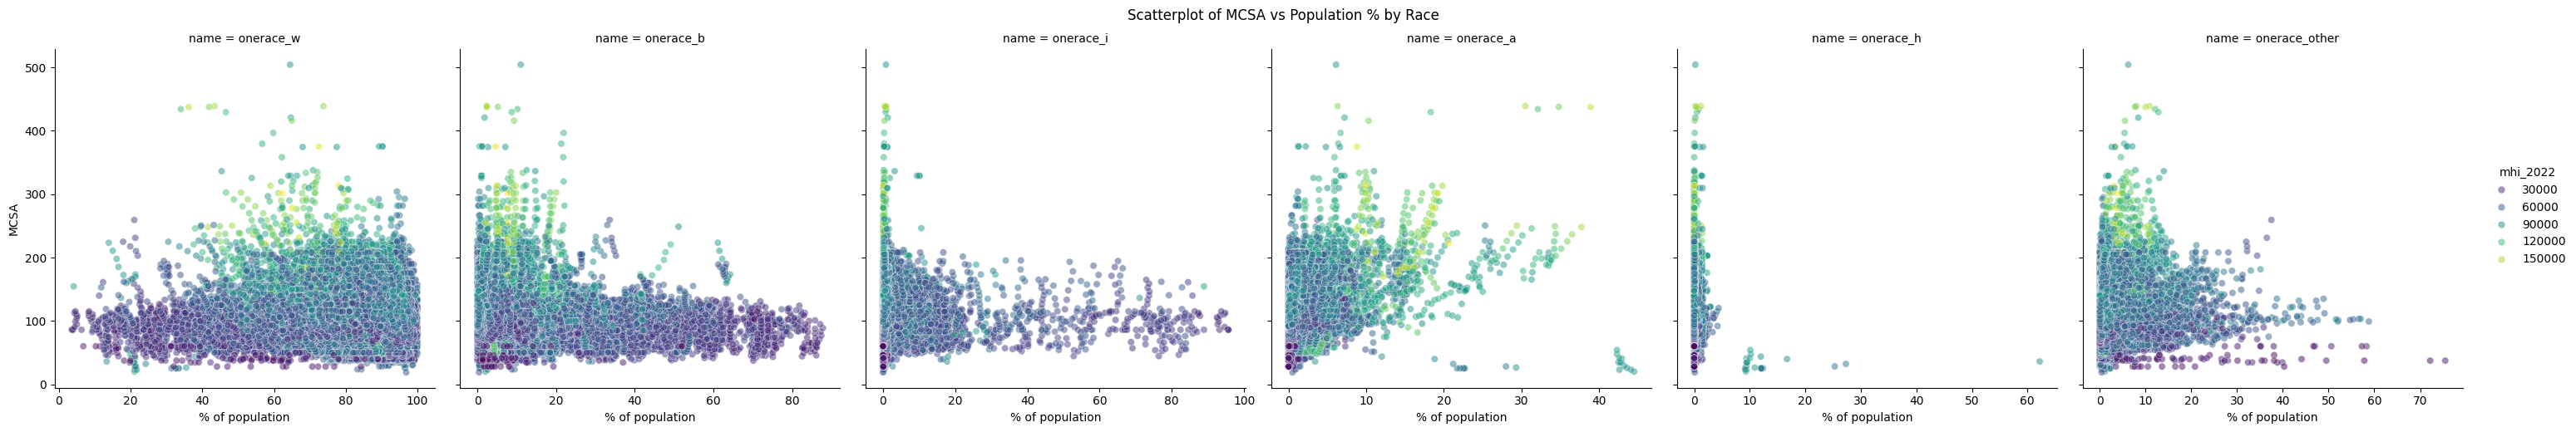

In [17]:
long_data = childcare_costs.melt(
    id_vars=['mcsa', 'mhi_2022'], 
    value_vars=[col for col in childcare_costs.columns if col.startswith('onerace_')],
    var_name='name', 
    value_name='value'
)

sns.relplot(
    data=long_data, 
    x='value', y='mcsa', hue='mhi_2022', col='name', 
    kind='scatter', palette='viridis', alpha=0.5, facet_kws={'sharex': False, 'sharey': True}
).set_axis_labels("% of population", "MCSA").figure.suptitle("Scatterplot of MCSA vs Population % by Race", y=1.03)

plt.show()

How are childcare costs related to mhi_2022 (median household income) and flfpr_20to64 (labor force participation for women)?

ValueError: Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.

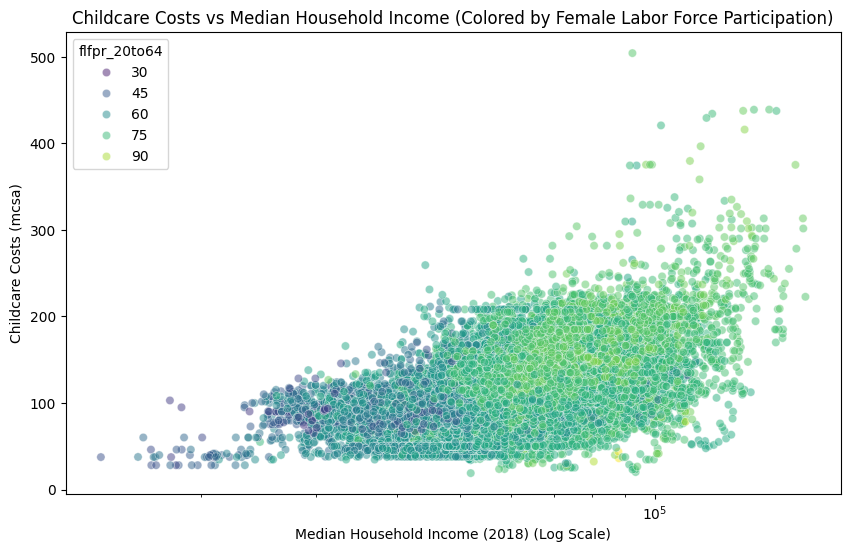

In [93]:
plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(
    data=childcare_costs,
    x='mhi_2022',  # Median household income in 2018
    y='mcsa',      # Childcare costs
    hue='flfpr_20to64',  # Female labor force participation rate
    palette='viridis',   # Viridis color palette
    alpha=0.5            # Transparency
)

# Apply a log scale to the x-axis
plt.xscale('log')

# Add labels and title
plt.title('Childcare Costs vs Median Household Income (Colored by Female Labor Force Participation)')
plt.xlabel('Median Household Income (2018) (Log Scale)')
plt.ylabel('Childcare Costs (mcsa)')

# Add a color bar for the legend
norm = plt.Normalize(childcare_costs['flfpr_20to64'].min(), childcare_costs['flfpr_20to64'].max())
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm)
cbar.set_label('Female Labor Force Participation (20-64)')

plt.grid(True, alpha=0.3)
plt.show()

In [94]:
clustering_data = childcare_costs_cleaned[['state_name','county_name', 'mcsa', 'mhi_2022', 'unr_20to64', 'flfpr_20to64','totalpop','onerace_w','onerace_b','onerace_i','onerace_a','onerace_h','onerace_other']]

# Drop rows with missing values
clustering_data = clustering_data.dropna()

# Remove the county name column for clustering
X = clustering_data.drop(columns=['state_name','county_name'])
X_scaled = scaler.fit_transform(X)

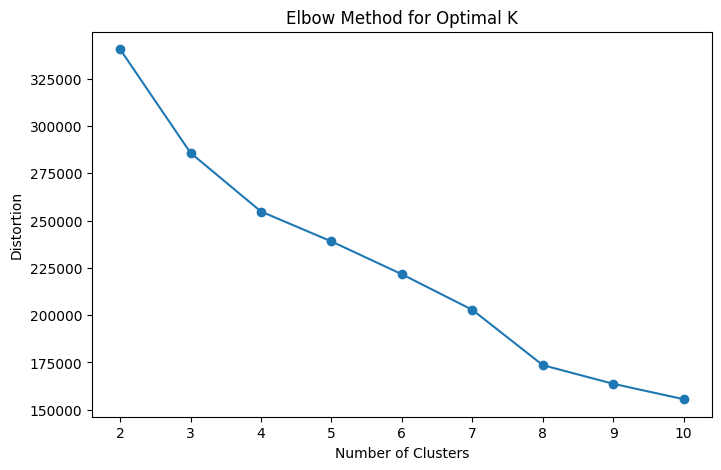

In [95]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

distortions = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    distortions.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), distortions, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Distortion')
plt.title('Elbow Method for Optimal K')
plt.show()

In [96]:
# Range of clusters to test
clusters = range(2, 11)
silhouette_scores = []

# Calculate silhouette score for each number of clusters
for k in clusters:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    labels = kmeans.predict(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, labels)
    silhouette_scores.append(silhouette_avg)
    print(f'n_clusters = {k}; avg. silhouette_score = {silhouette_avg:.5f}')

n_clusters = 2; avg. silhouette_score = 0.39909
n_clusters = 3; avg. silhouette_score = 0.34343
n_clusters = 4; avg. silhouette_score = 0.19310
n_clusters = 5; avg. silhouette_score = 0.18826
n_clusters = 6; avg. silhouette_score = 0.15372
n_clusters = 7; avg. silhouette_score = 0.19457
n_clusters = 8; avg. silhouette_score = 0.21398
n_clusters = 9; avg. silhouette_score = 0.18718
n_clusters = 10; avg. silhouette_score = 0.16840


In [97]:
kmeans = KMeans(n_clusters=2, random_state=42)
clustering_data['cluster'] = kmeans.fit_predict(X_scaled)

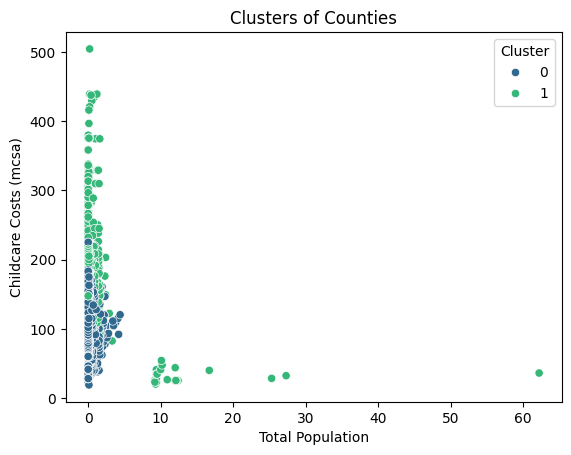

In [106]:
sns.scatterplot(
    x='onerace_h', y='mcsa', hue='cluster', data=clustering_data, palette='viridis'
)
plt.title('Clusters of Counties')
plt.xlabel('Total Population')
plt.ylabel('Childcare Costs (mcsa)')
plt.legend(title='Cluster')
plt.show()

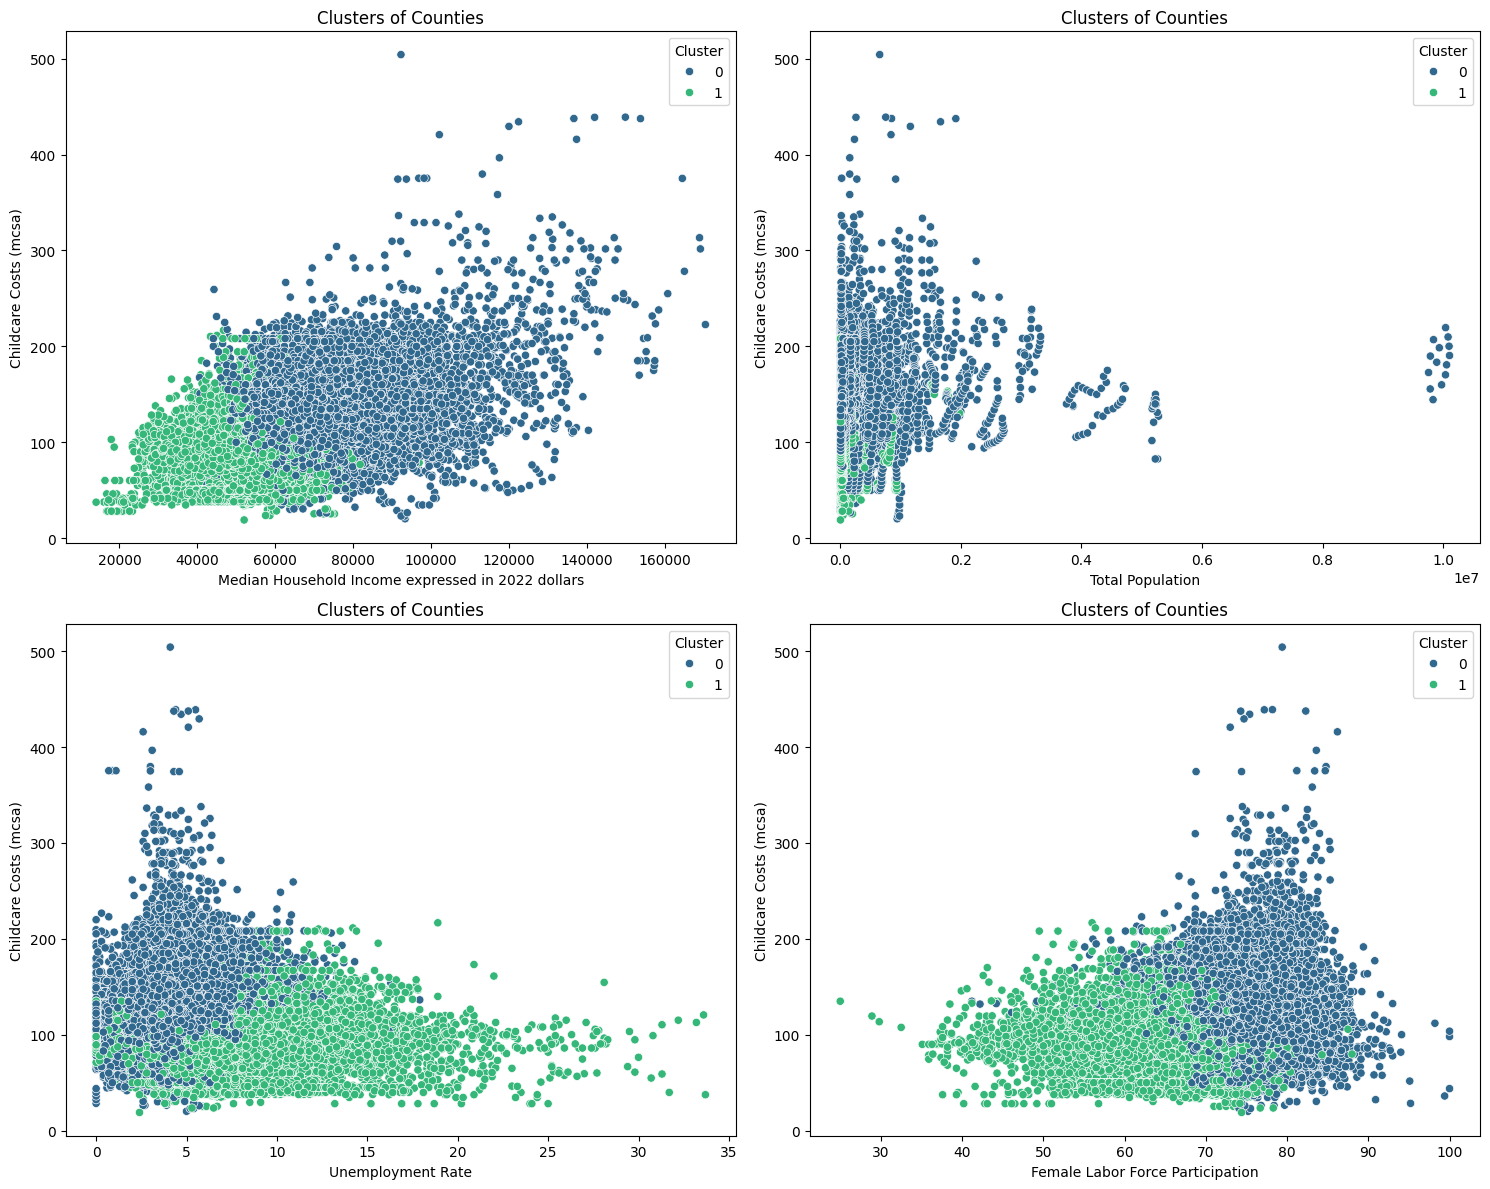

In [92]:

fig, axes = plt.subplots(2, 2, figsize=(15, 12))  # 2 rows, 2 columns

# Plot 1: Median Household Income vs Childcare Costs
sns.scatterplot(
    x='mhi_2022', y='mcsa', hue='cluster', data=clustering_data, palette='viridis', ax=axes[0, 0]
)
axes[0, 0].set_title('Clusters of Counties')
axes[0, 0].set_xlabel('Median Household Income expressed in 2022 dollars')
axes[0, 0].set_ylabel('Childcare Costs (mcsa)')
axes[0, 0].legend(title='Cluster', loc='best')

# Plot 2: Total Population vs Childcare Costs
sns.scatterplot(
    x='totalpop', y='mcsa', hue='cluster', data=clustering_data, palette='viridis', ax=axes[0, 1]
)
axes[0, 1].set_title('Clusters of Counties')
axes[0, 1].set_xlabel('Total Population')
axes[0, 1].set_ylabel('Childcare Costs (mcsa)')
axes[0, 1].legend(title='Cluster', loc='best')

# Plot 3: Unemployment Rate vs Childcare Costs
sns.scatterplot(
    x='unr_20to64', y='mcsa', hue='cluster', data=clustering_data, palette='viridis', ax=axes[1, 0]
)
axes[1, 0].set_title('Clusters of Counties')
axes[1, 0].set_xlabel('Unemployment Rate')
axes[1, 0].set_ylabel('Childcare Costs (mcsa)')
axes[1, 0].legend(title='Cluster', loc='best')

# Plot 4: Female Labor Force Participation vs Childcare Costs
sns.scatterplot(
    x='flfpr_20to64', y='mcsa', hue='cluster', data=clustering_data, palette='viridis', ax=axes[1, 1]
)
axes[1, 1].set_title('Clusters of Counties')
axes[1, 1].set_xlabel('Female Labor Force Participation')
axes[1, 1].set_ylabel('Childcare Costs (mcsa)')
axes[1, 1].legend(title='Cluster', loc='best')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

In [104]:
clustering_data.groupby(['cluster']).mean('mcsa')

,mcsa,mhi_2022,unr_20to64,flfpr_20to64,totalpop,onerace_w,onerace_b,onerace_i,onerace_a,onerace_h,onerace_other
cluster,,,,,,,,,,,
0,101.048886,57307.430274,6.395732,69.128617,51794.543024,83.960699,9.041933,1.868244,0.742096,0.057344,1.764672
1,160.607042,86869.481359,5.753963,74.955951,607893.621099,72.692958,9.793344,0.736233,6.008092,0.236288,6.179812
